In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [12]:
df=pd.read_csv("../../data/raw/flight_dataset.csv");

In [78]:
df.head()

,Unnamed: 0,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [13]:
df.shape

(14640, 16)

In [14]:
df.columns

Index(['Unnamed: 0', 'tweet_id', 'airline_sentiment',
       'airline_sentiment_confidence', 'negativereason',
       'negativereason_confidence', 'airline', 'airline_sentiment_gold',
       'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord',
       'tweet_created', 'tweet_location', 'user_timezone'],
      dtype='str')

In [15]:
df['airline_sentiment'].head(10)

0     neutral
1    positive
2     neutral
3    negative
4    negative
5    negative
6    positive
7     neutral
8    positive
9    positive
Name: airline_sentiment, dtype: str

In [ ]:
df['airline_sentiment'].isnull().sum()

np.int64(0)

In [17]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

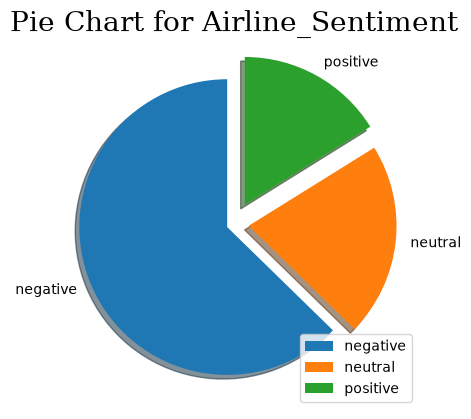

In [43]:
myexplode=[0.05,0.1,0.15]
front_dict={'family':'serif','color':'#000','size':20}
mylabels=['negative','neutral','positive']
plt.pie(df['airline_sentiment'].value_counts(),startangle=90,labels=mylabels,shadow=True,explode=myexplode)
plt.legend()
plt.title('Pie Chart for Airline_Sentiment',fontdict=front_dict)
plt.show() 

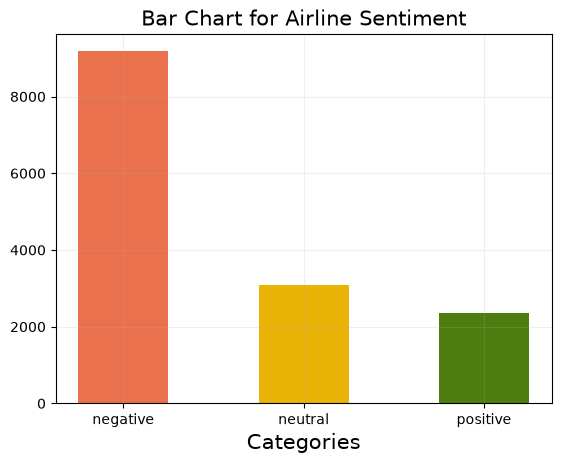

In [71]:
counts=df['airline_sentiment'].value_counts()
col=['#E9724D','#EAB308','#4D7C0F']
front_dict={'color':'#000','size':15}

plt.bar(counts.index,counts.values,width=0.5,color=col)
plt.title('Bar Chart for Airline Sentiment',fontdict=front_dict)
plt.xlabel('Categories',fontdict=front_dict)
plt.grid(alpha=0.2)
plt.show()

In [80]:
duplicates = df[df["text"].duplicated(keep=False)].sort_values("text")
duplicates[["text", "airline_sentiment"]].head(20)


,text,airline_sentiment
12067,.@AmericanAir can you connect me to a person w...,negative
11906,.@AmericanAir can you connect me to a person w...,negative
11902,.@AmericanAir just disappointed with the Fligh...,neutral
12063,.@AmericanAir just disappointed with the Fligh...,neutral
11946,@AmericanAir\n Your response could have made a...,negative
12107,@AmericanAir\n Your response could have made a...,negative
12128,@AmericanAir \nIt's not what happens to us tha...,negative
11967,@AmericanAir \nIt's not what happens to us tha...,negative
13995,@AmericanAir 800 number will not even let you...,negative
12029,@AmericanAir 800 number will not even let you...,negative


In [81]:
duplicate_groups = (
    df.groupby("text")["airline_sentiment"]
      .nunique()
)

duplicate_groups.value_counts()

airline_sentiment
1    14402
2       25
Name: count, dtype: int64

In [83]:
df.drop_duplicates(subset=['text','airline_sentiment'],keep="first",inplace=True)

In [86]:
from sklearn.preprocessing import LabelEncoder

In [87]:
Encoder=LabelEncoder()

In [88]:
df['label']=Encoder.fit_transform(df['airline_sentiment'])

In [90]:
df['label'].value_counts()

label
0    9087
1    3067
2    2298
Name: count, dtype: int64

In [92]:
import joblib
joblib.dump(Encoder,'../../models/tfidf/Encoder_sentiment.pkl')

['../../models/tfidf/Encoder_sentiment.pkl']